F)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.ticker import MultipleLocator

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import mean_squared_error

from NeuralNetwork import NeuralNetwork
from Scheduler import *
from functions import *

import _LinearRegression
import OLS

import seaborn as sns

In [2]:
from sklearn.datasets import fetch_openml

# Fetch the MNIST dataset
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')

# Extract data (features) and target (labels)
X = mnist.data
y = mnist.target

In [3]:
# Scaling
X = X/255

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2025)

# Convert elements from str to int type
y_train = y_train.astype("int")
y_test = y_test.astype("int")

y_train = y_train.reshape(-1,1)
y_test = y_test.reshape(-1,1)

In [4]:
def accuracy(pred, target):
    return np.mean(pred == target)

def dummy(x):
    return None

In [61]:
np.random.seed(2025)

num_input_feats = X_train.shape[1] # Number of input features
num_output_feats = 10 # Number og output features

batch_size = 10000
epochs = 50

np.random.seed(2025)

scheduler = Adam(0.001)
ffnn = NeuralNetwork(num_input_feats, 
                    num_output_feats,
                    [100, 100],
                    [ReLU, ReLU, softmax], 
                    [ReLU_der, ReLU_der, id_func_der],
                    scheduler,
                    cost_func= dummy,
                    cost_func_der= dummy,
                    classifier_mode=True,
                    regularization=None, 
                    reg_param=0,
                    seed=2025
                    )

#Train
ffnn.train(X_train, y_train, batch_size, epochs)
# Predict
test_pred = ffnn.predict(X_test)

In [59]:
predict_test_labels = np.argmax(test_pred, axis=1)

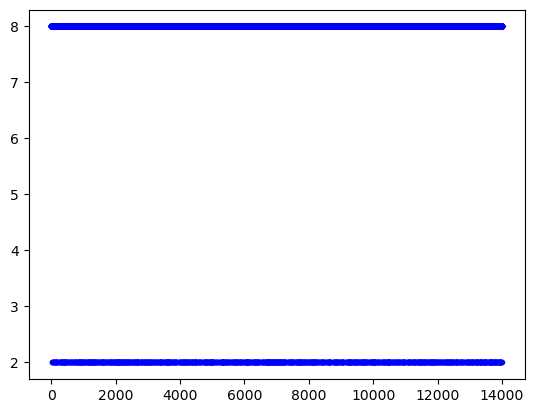

In [60]:
plt.plot(predict_test_labels,"b.")

In [57]:
accuracy(predict_test_labels, y_test)

np.float64(0.10199010714285714)